In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv("../data/train.csv")

test_df = pd.read_csv("../data/test.csv")

In [3]:
print(f"Training Dataset Shape : {train_df.shape}")

print(f"Testing Dataset Shape : {test_df.shape}")

Training Dataset Shape : (1460, 81)
Testing Dataset Shape : (1459, 80)


In [4]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train_df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [6]:
train_df.sample(5, random_state=42)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
892,893,20,RL,70.0,8414,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal,154500
1105,1106,60,RL,98.0,12256,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,325000
413,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,115000
522,523,50,RM,50.0,5000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,Normal,159000
1036,1037,20,RL,89.0,12898,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,315500


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Observation

- The training dataset contains **1,460 rows** and **81 columns**.
- The dataset consists of **35 integer features**, **3 floating-point features**, and **43 categorical (object) features**.
- The target variable is **SalePrice**, which represents the selling price of each house.
- Several features contain missing values, indicating that data preprocessing and imputation will be required before model training.
- The dataset contains a mix of numerical and categorical variables, so appropriate preprocessing techniques (such as scaling and encoding) will be required before training machine learning models.

In [8]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [9]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing = missing.sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(train_df)) * 100
})

missing_df

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


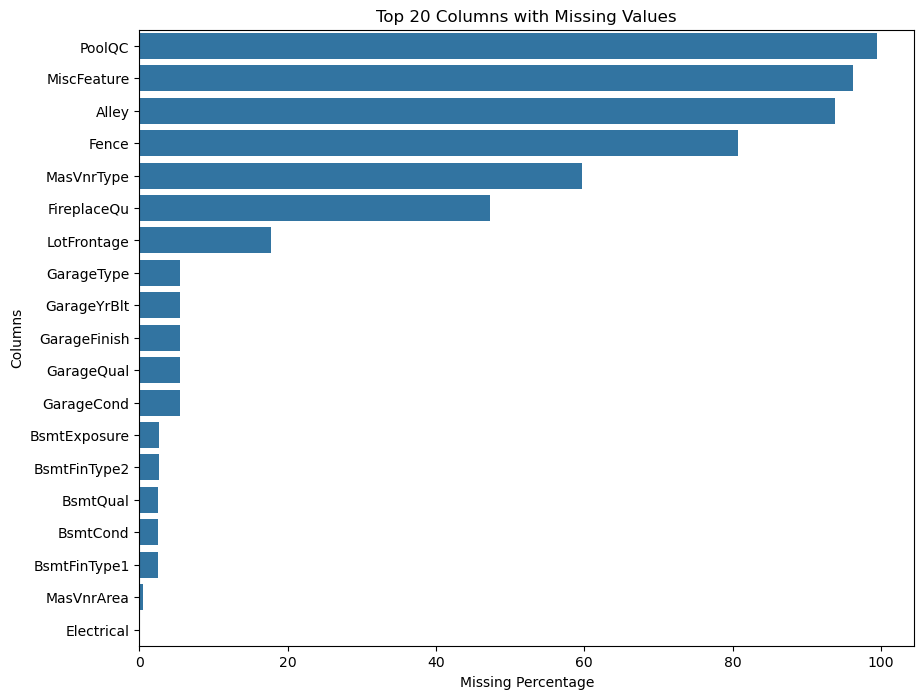

In [10]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=missing_df.head(20),
    x="Percentage",
    y=missing_df.head(20).index
)

plt.title("Top 20 Columns with Missing Values")

plt.xlabel("Missing Percentage")

plt.ylabel("Columns")

plt.show()

In [11]:
duplicates = train_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [12]:
train_df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [13]:
num_cols = train_df.select_dtypes(
    include=["int64", "float64"]
).columns

cat_cols = train_df.select_dtypes(
    include=["object"]
).columns

print(f"Number of Numerical Features : {len(num_cols)}")

print(f"Number of Categorical Features : {len(cat_cols)}")

Number of Numerical Features : 38
Number of Categorical Features : 43


In [14]:
df = train_df.copy()

Exploratory Data Analysis (EDA)

Numerical Feature Distribution

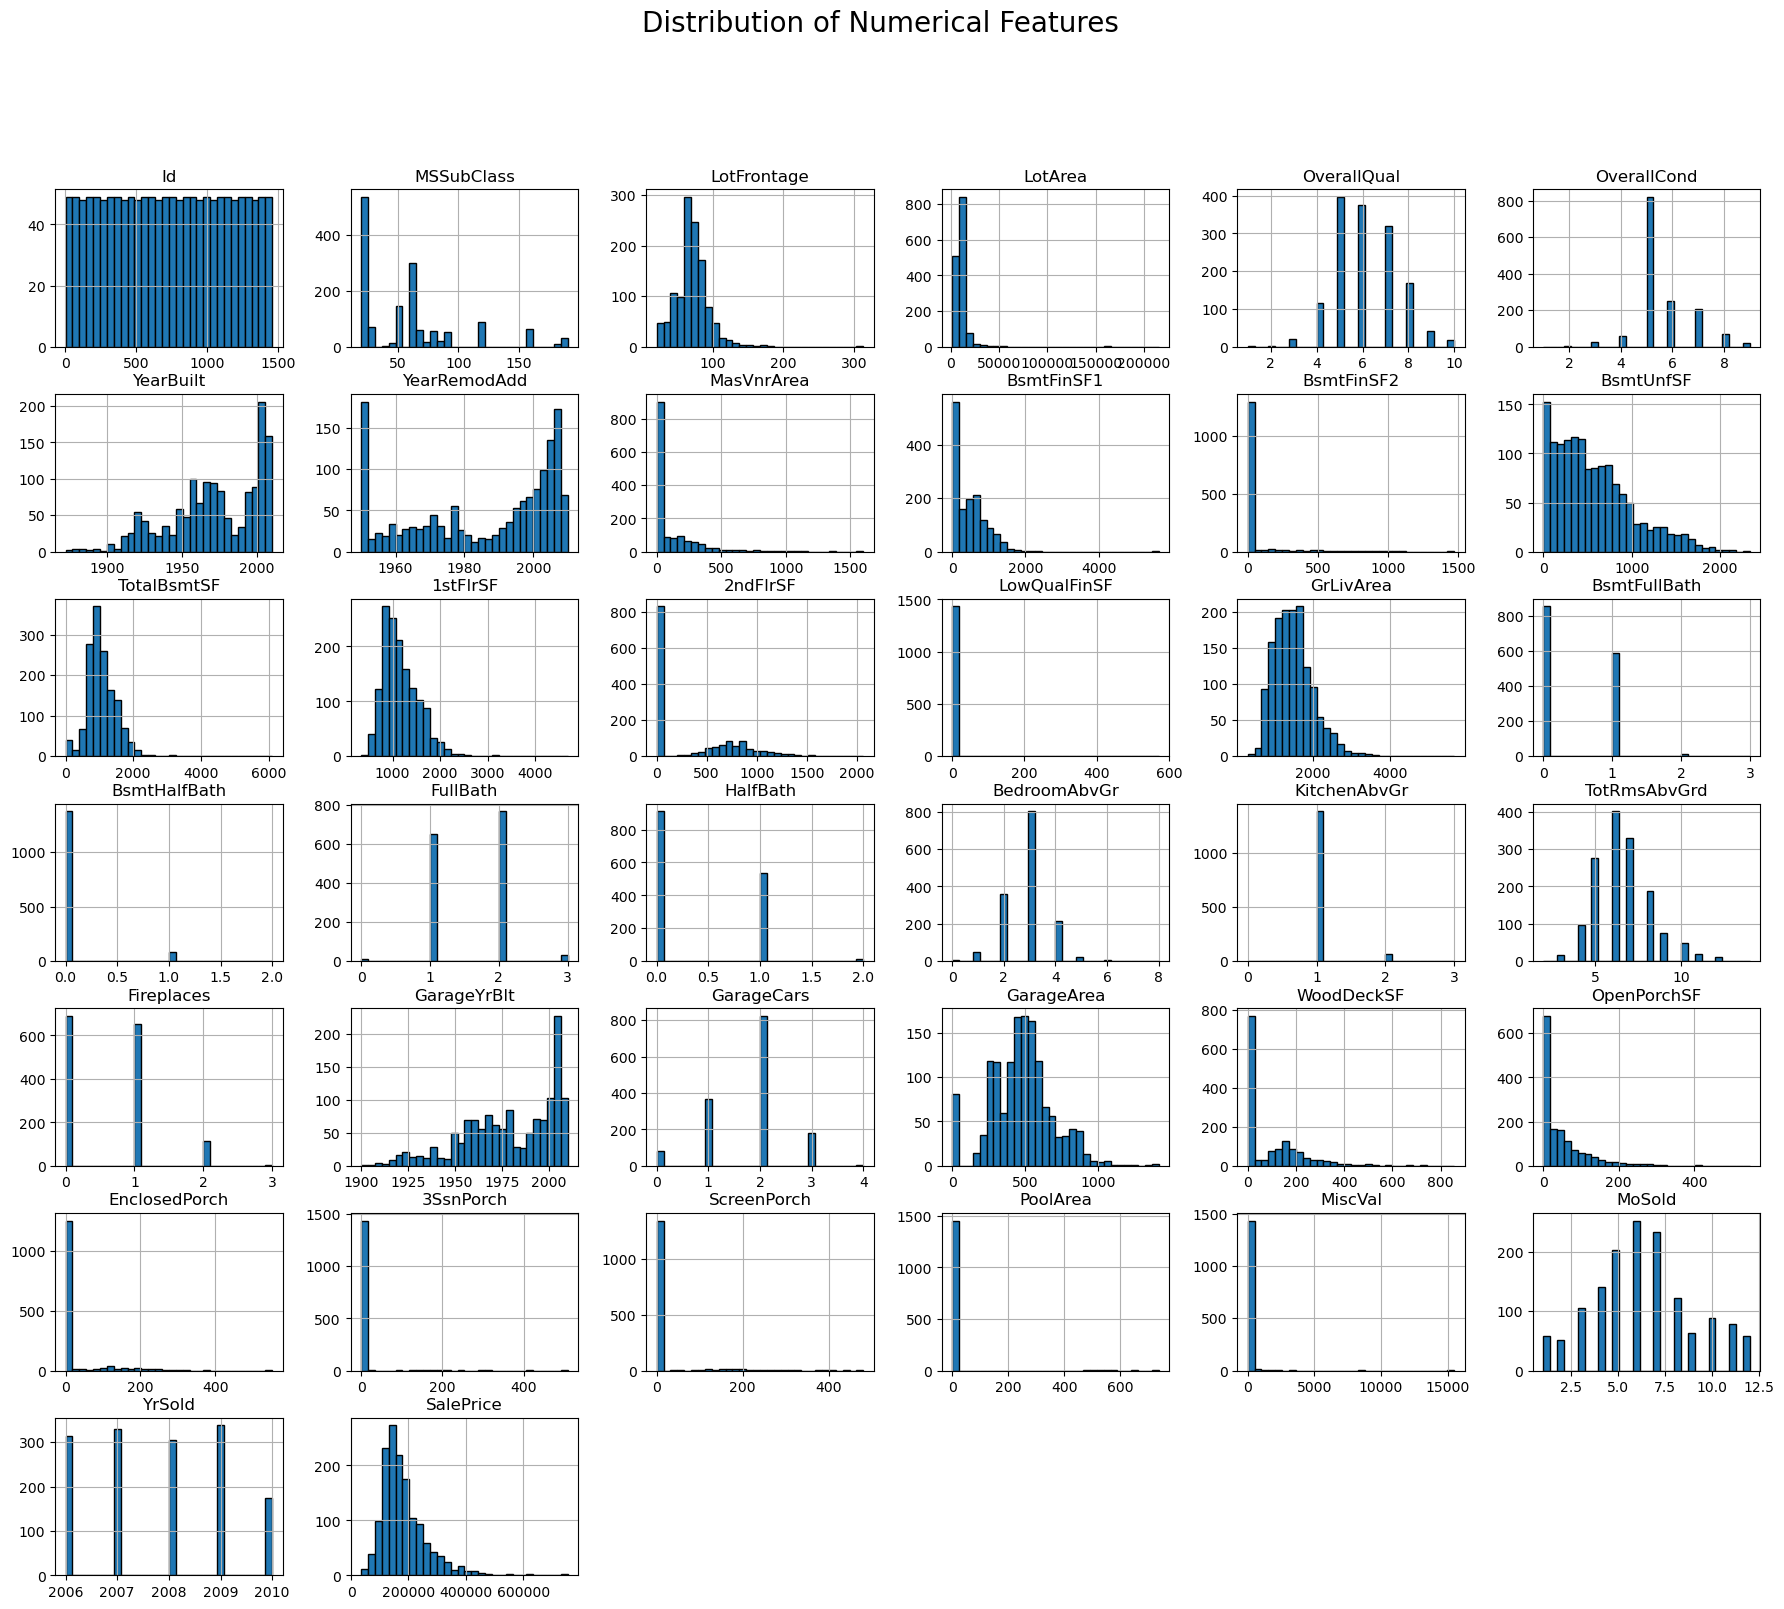

In [15]:
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

train_df[numerical_cols].hist(
    figsize=(22,18),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=20)

plt.show()

Target Variable Analysis

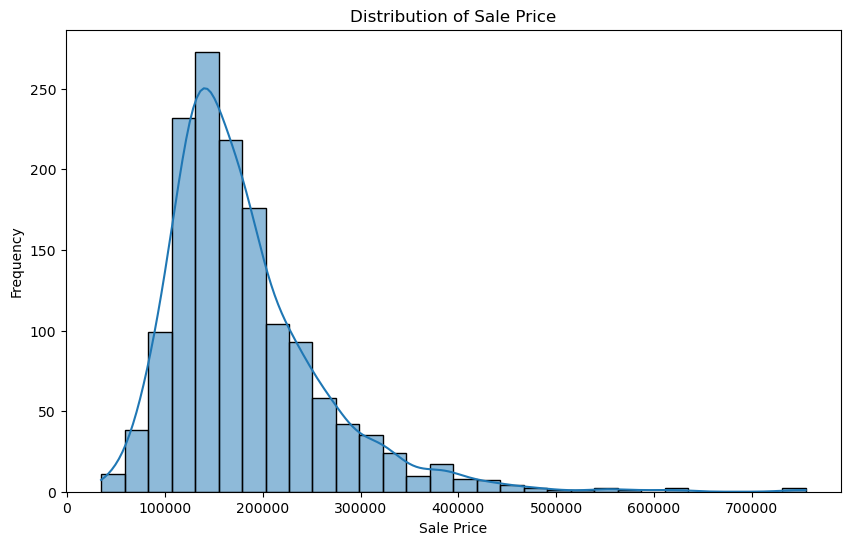

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    train_df["SalePrice"],
    kde=True,
    bins=30
)

plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

#Observation

- The target variable is positively skewed.
- Most houses are concentrated in the lower to mid-price range.
- A few expensive properties create a long right tail.
- Applying a logarithmic transformation may improve model performance for some regression algorithms.

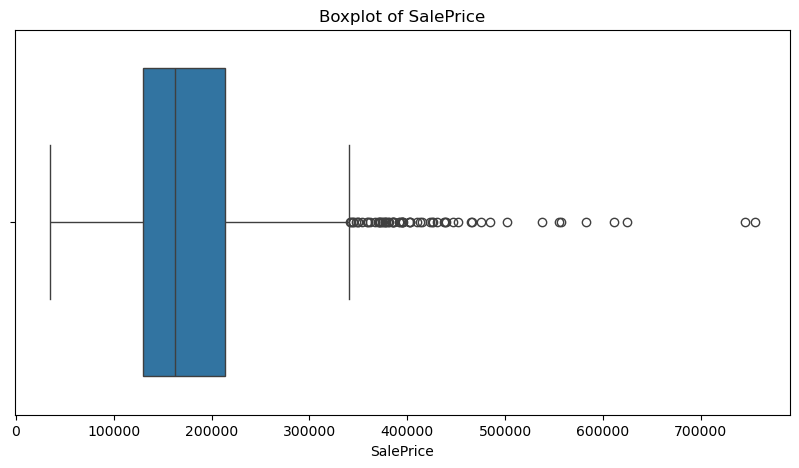

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(x=train_df["SalePrice"])

plt.title("Boxplot of SalePrice")

plt.show()

#Observation

The boxplot indicates the presence of several high-value outliers in the target variable. These observations may represent luxury properties rather than data errors and should be carefully evaluated before removal.

Correlation Heatmap

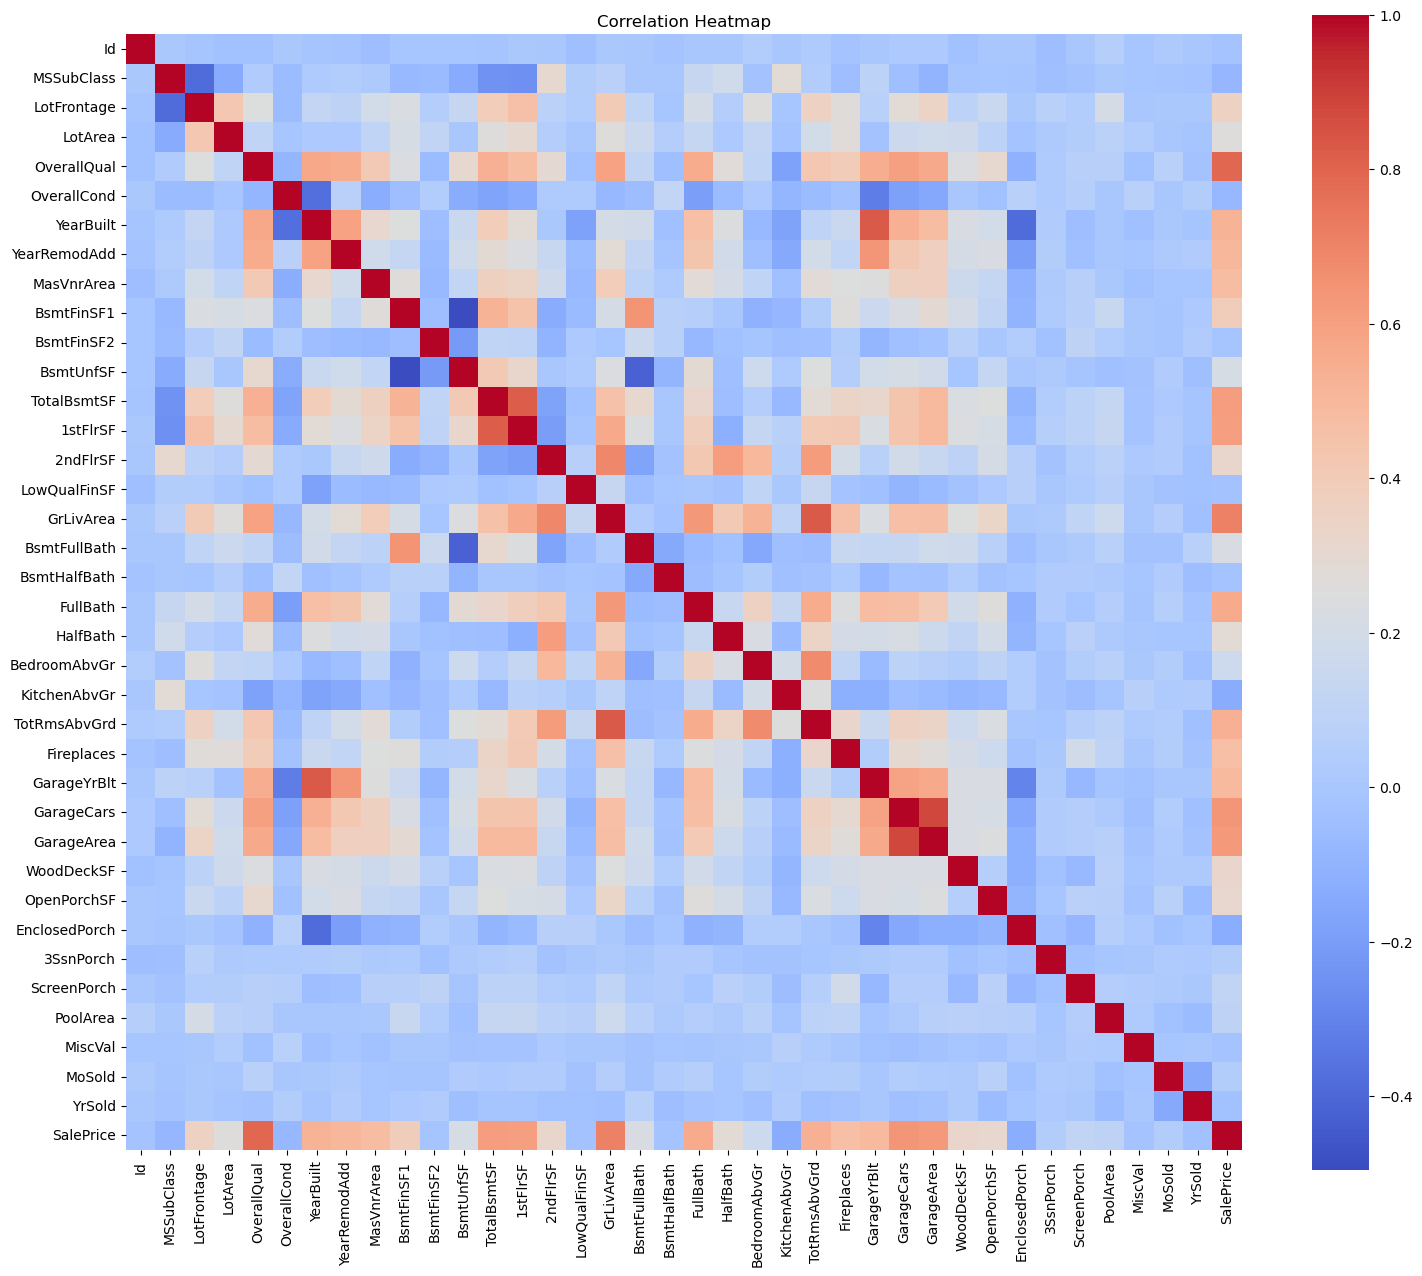

In [18]:
plt.figure(figsize=(18,15))

corr = train_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap")

plt.show()

Top Correlated Features

In [19]:
corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

#Observation

OverallQual has the strongest positive correlation with SalePrice (0.79).

GrLivArea also exhibits a strong positive relationship (0.71).

GarageCars and GarageArea are important predictors with correlations above 0.62.

Categorical Feature Analysis

In [20]:
important_cat = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "GarageType",
    "SaleCondition",
    "MSZoning"
]

Outlier Detection

In [21]:
important_num = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageArea",
    "SalePrice"
]

Relationship with Target

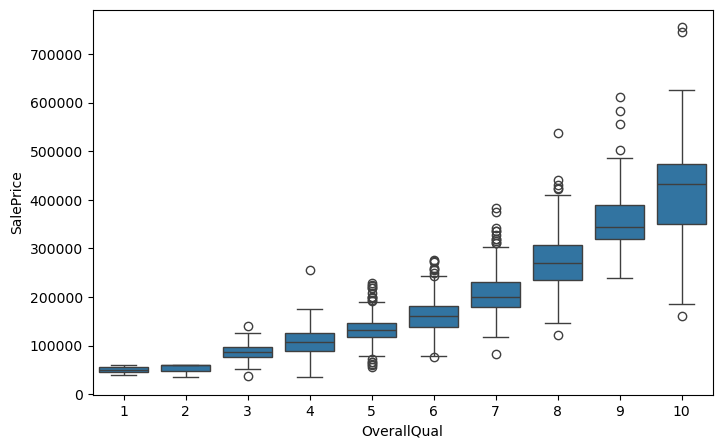

In [22]:
#OverallQual
plt.figure(figsize=(8,5))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=train_df
)

plt.show()

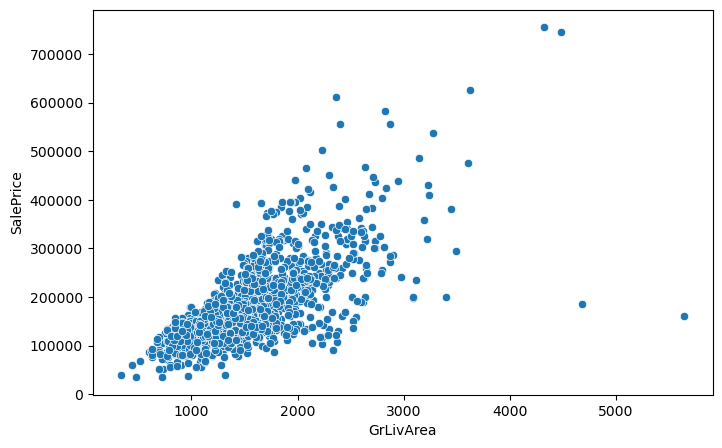

In [23]:
#GrLivArea
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train_df,
    x="GrLivArea",
    y="SalePrice"
)

plt.show()

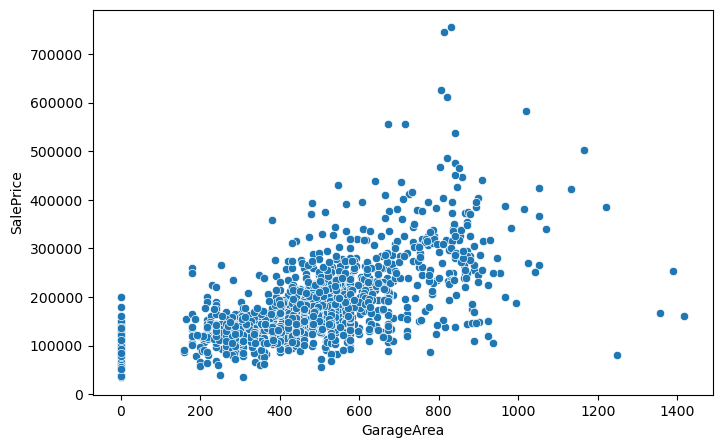

In [24]:
#GarageArea
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train_df,
    x="GarageArea",
    y="SalePrice"
)

plt.show()

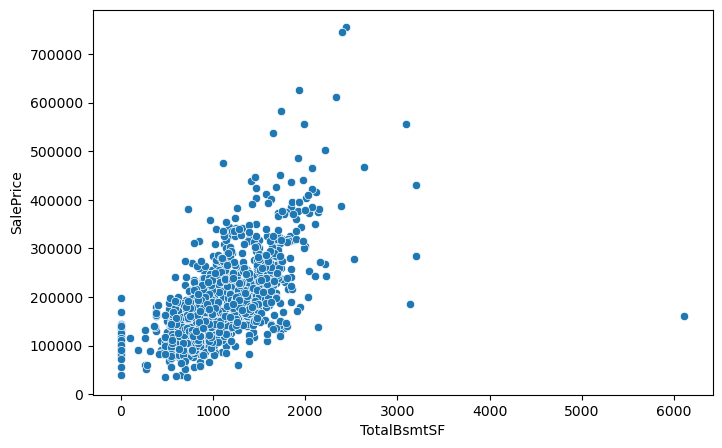

In [25]:
#TotalBsmtSF
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train_df,
    x="TotalBsmtSF",
    y="SalePrice"
)

plt.show()


Pairplot

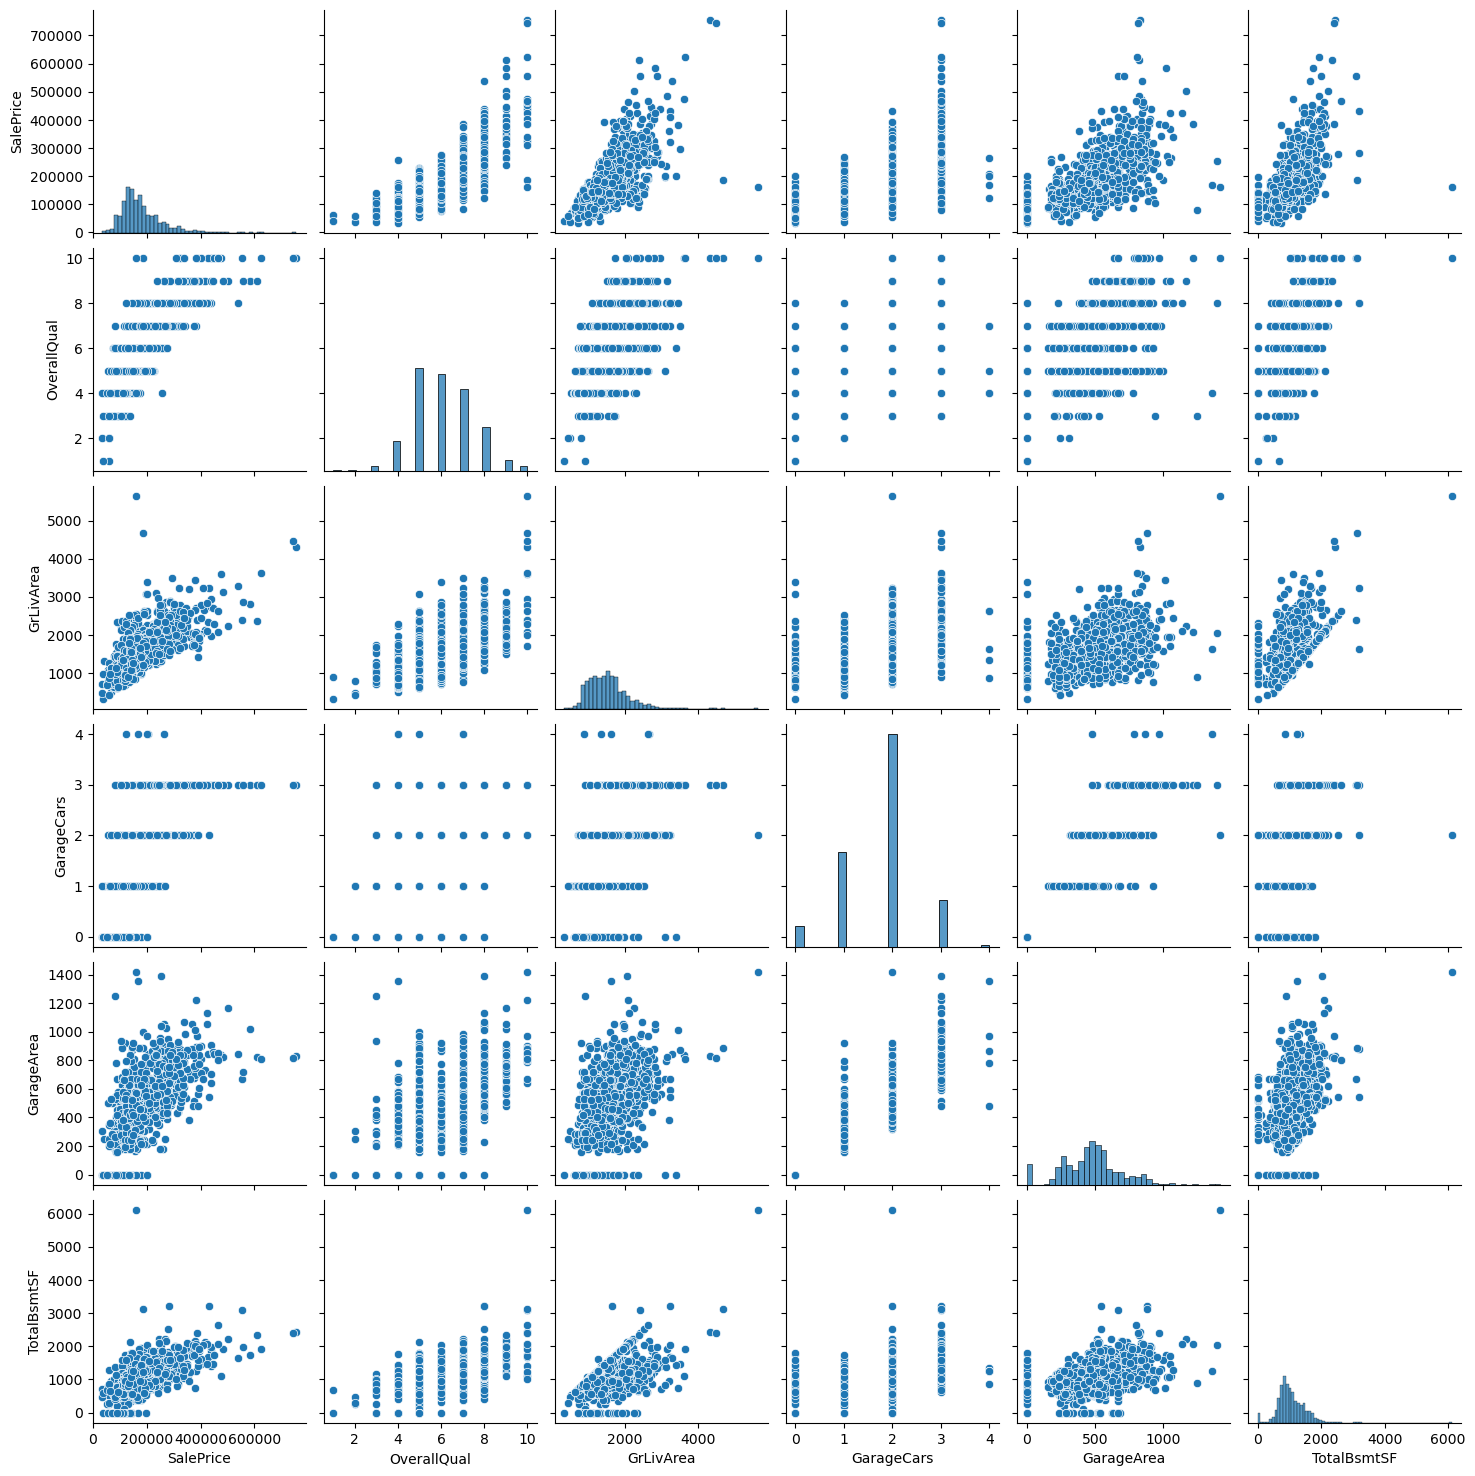

In [26]:
selected_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF"
]

sns.pairplot(train_df[selected_features])

plt.show()

Target Variable Transformation

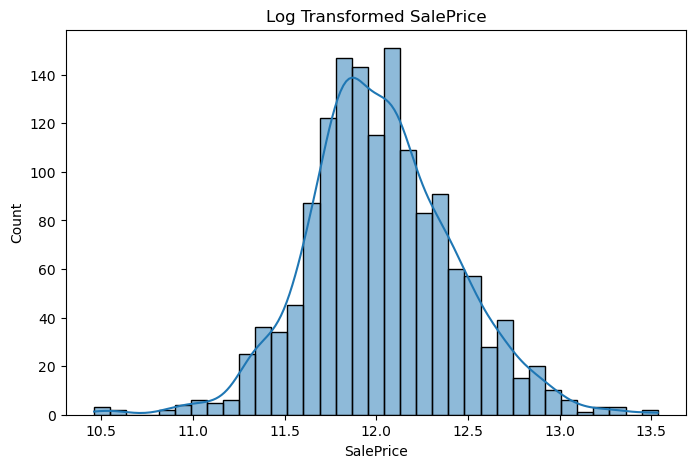

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(train_df["SalePrice"]), kde=True)

plt.title("Log Transformed SalePrice")

plt.show()

Observation

The log transformation reduces skewness and produces a distribution closer to normal.

This transformation can improve the performance of linear regression models.

Exploratory Data Analysis revealed that the dataset contains missing values, skewed numerical features, and several strong predictors of house prices such as OverallQual, GrLivArea, and GarageArea. These insights will guide the preprocessing and feature engineering steps before model training.

Data Cleaning & Feature Engineering

In [28]:
# Target variable
y = train_df["SalePrice"]

# Input features
X = train_df.drop("SalePrice", axis=1)

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (1460, 80)
Target Shape   : (1460,)


Drop Unnecessary Columns

In [29]:
# Remove ID column
X = X.drop("Id", axis=1)

# Remove from test dataset as well
test_ids = test_df["Id"]
test_df = test_df.drop("Id", axis=1)

print("Training Features Shape :", X.shape)
print("Test Dataset Shape      :", test_df.shape)

Training Features Shape : (1460, 79)
Test Dataset Shape      : (1459, 79)


In [30]:
# Separate numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Features :", len(numerical_cols))
print("Categorical Features :", len(categorical_cols))

Numerical Features : 36
Categorical Features : 43


### Creating Imputation Pipelines

Different imputation strategies are applied based on the data type of each feature.

- **Numerical features:** Missing values are replaced with the median, which is robust to outliers.
- **Categorical features:** Missing values are replaced with the most frequently occurring category to preserve the existing data distribution.

In [31]:
from sklearn.impute import SimpleImputer

# Numerical Imputer
numeric_transformer = SimpleImputer(strategy="median")

# Categorical Imputer
categorical_transformer = SimpleImputer(strategy="most_frequent")

### Encoding Categorical Features

Machine learning algorithms require numerical input. Therefore, categorical features are transformed using **One-Hot Encoding**.

One-Hot Encoding creates binary columns for each category without introducing any ordinal relationship between them. Unknown categories encountered during prediction are ignored to ensure robustness.

In [32]:
# One-Hot Encoder
encoder = OneHotEncoder(
    handle_unknown="ignore"
)

### Creating Preprocessing Pipelines

To ensure a clean and reusable workflow, preprocessing steps are grouped into separate pipelines for numerical and categorical features.

- The numerical pipeline imputes missing values using the median.
- The categorical pipeline imputes missing values using the most frequent category and then applies One-Hot Encoding.

This modular approach improves code readability, reusability, and consistency across training and test datasets.

In [33]:
from sklearn.pipeline import Pipeline

# Numerical Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### Combining Preprocessing Steps

A `ColumnTransformer` is used to apply different preprocessing techniques to numerical and categorical features simultaneously.

This ensures that each feature type is processed appropriately while maintaining a single, unified preprocessing workflow.

In [34]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [35]:
X_processed = preprocessor.fit_transform(X)

print("Original Shape :", X.shape)
print("Processed Shape:", X_processed.shape)

Original Shape : (1460, 79)
Processed Shape: (1460, 287)


##Observation

- The preprocessing pipeline successfully transformed the dataset without changing the number of observations.
- The number of features increased from **79** to **287** due to **One-Hot Encoding**, which expanded categorical variables into multiple binary columns.
- Numerical features were imputed using the **median**, while categorical features were imputed using the **most frequent category** before encoding.
- The transformed dataset is now ready for machine learning model training.

# Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of machine learning models on unseen data.

An **80:20 split** is used, where **80%** of the data is used for training and **20%** is reserved for testing.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1168, 79)
Testing Features  : (292, 79)
Training Labels   : (1168,)
Testing Labels    : (292,)


### Model Training and Evaluation

In this phase, multiple regression algorithms are trained and evaluated using the same preprocessing pipeline. Comparing different models helps identify the algorithm that best predicts house prices.

In [37]:
from xgboost import XGBRegressor
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    )
}

In [43]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R² Score": round(r2, 4)
    })

# ⭐ This line was missing
results_df = pd.DataFrame(results)

# Sort
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R² Score
0,Gradient Boosting,16535.11,26327.98,0.9096
1,XGBoost,17680.41,27656.79,0.9003
2,Lasso Regression,17919.80,28239.65,0.8960
3,Random Forest,17394.56,28396.30,0.8949
4,Linear Regression,20519.77,31336.83,0.8720
5,Ridge Regression,20574.71,34562.05,0.8443
6,Decision Tree,26452.03,41191.30,0.7788


### Observation

Seven regression models were trained and evaluated using identical preprocessing steps to ensure a fair comparison.

Among all the models, **Gradient Boosting Regressor** achieved the highest performance with an **R² Score of 0.9096**, along with the lowest MAE and RMSE values.

Tree-based ensemble methods such as Gradient Boosting, Random Forest, and XGBoost outperformed linear models, indicating that the relationship between house features and sale prices is non-linear.

Based on these results, **Gradient Boosting Regressor** was selected for further optimization through hyperparameter tuning.

# Hyperparameter Tuning

Hyperparameter tuning is performed to improve the performance of the selected machine learning model.

`GridSearchCV` is used to evaluate different combinations of hyperparameters using cross-validation. The combination that produces the best validation score is selected as the final model.

In [ ]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

## Defining the Hyperparameter Search Space

A grid of hyperparameters is defined to explore different model configurations. GridSearchCV evaluates every combination to identify the best-performing model.

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__subsample": [0.8, 1.0]
}

Performing Hyperparameter Tuning

Five-fold cross-validation is used to evaluate each hyperparameter combination. The model with the highest validation performance is selected automatically.

In [ ]:
grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'L...
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 4],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='r2', verbose=2)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best Cross Validation Score:
0.8654240048389024


###  Observation

GridSearchCV identified the optimal hyperparameter combination for the Gradient Boosting Regressor using five-fold cross-validation.

The selected model uses **200 estimators**, a **maximum tree depth of 4**, a **learning rate of 0.1**, and a **subsample ratio of 0.8**.

The best average cross-validation R² score achieved during tuning was **0.8654**, indicating good generalization performance across different validation folds.

# Final Model Evaluation

The optimized Gradient Boosting model is trained using the best hyperparameters obtained from GridSearchCV. Its performance is then evaluated on the unseen test dataset.

In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE      : 15901.08
RMSE     : 25889.42
R² Score : 0.9126


###  Observation

The optimized Gradient Boosting Regressor achieved better performance after hyperparameter tuning.

The final model obtained an **R² Score of 0.9126**, indicating that it explains approximately **91.26%** of the variance in house prices.

Additionally, both the **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** decreased compared to the baseline model, demonstrating that hyperparameter tuning improved the model's predictive accuracy.

Feature Importance

In [ ]:
# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

print("Total Features:", len(feature_names))

Total Features: 285


In [ ]:
# Extract feature importances
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,num__OverallQual,0.497717
15,num__GrLivArea,0.131054
25,num__GarageCars,0.041782
13,num__2ndFlrSF,0.036535
8,num__BsmtFinSF1,0.034004
12,num__1stFlrSF,0.033668
11,num__TotalBsmtSF,0.032471
2,num__LotArea,0.018796
245,cat__GarageFinish_Unf,0.018794
6,num__YearRemodAdd,0.013860


### Observation

The feature importance analysis indicates that **Overall Quality (`OverallQual`)** is the most influential predictor of house prices, contributing nearly **50%** of the model's overall importance.

Other significant features include **Above Ground Living Area (`GrLivArea`)**, **Garage Capacity (`GarageCars`)**, **Second Floor Area (`2ndFlrSF`)**, and **Finished Basement Area (`BsmtFinSF1`)**.

These results suggest that the overall quality, usable living space, garage capacity, and basement characteristics have the strongest impact on residential property prices in the Ames Housing dataset.

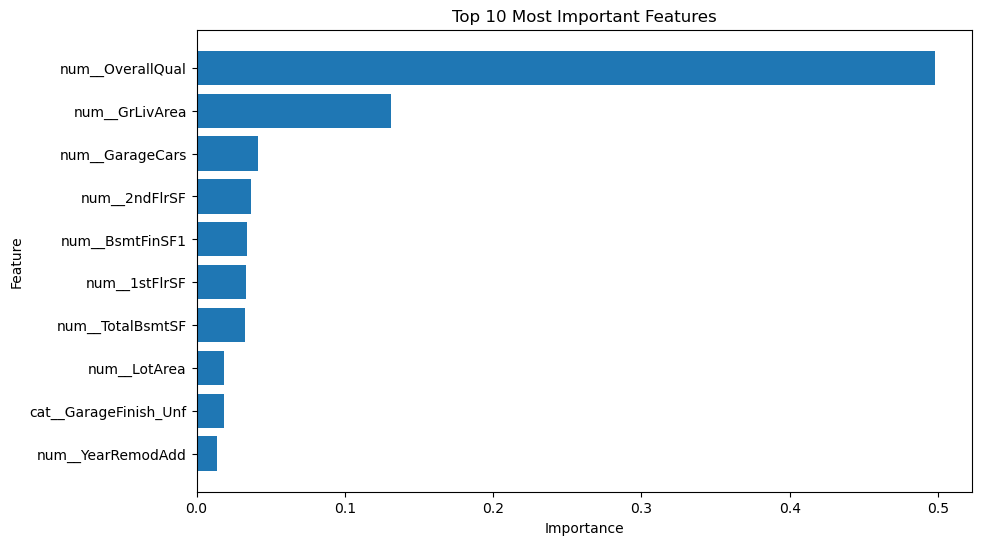

In [ ]:
# Top 10 Features
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

Actual vs Predicted Values

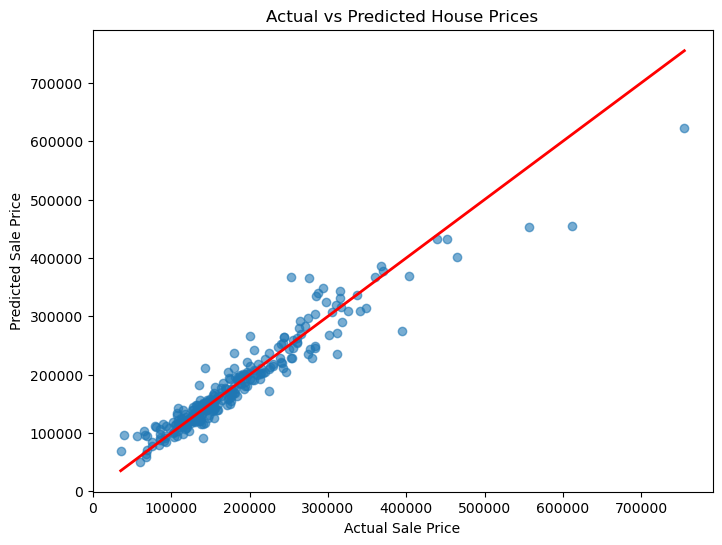

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Residual Analysis

Residuals represent the difference between the actual and predicted house prices.

A good regression model produces residuals that are randomly distributed around zero without any clear pattern.

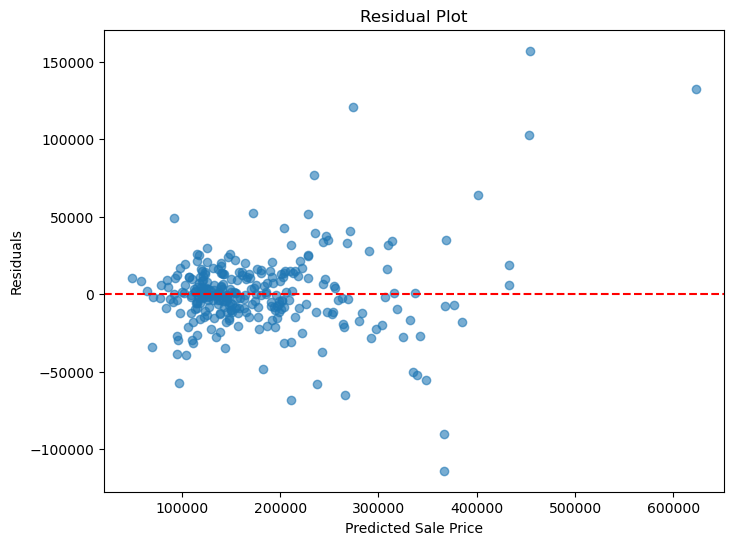

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

#  Predicting House Prices on the Test Dataset

The optimized model is used to predict house prices for the unseen test dataset. These predictions will be used to create the Kaggle submission file.

In [ ]:
test_predictions = best_model.predict(test_df)

print(test_predictions[:10])

[123438.04745541 151832.32946361 179974.86383502 195867.4584827
 199486.2057905  175956.39388435 178281.16121314 167859.54764176
 179955.05978389 125044.31356909]


Creating the Submission File

The predicted house prices are combined with the corresponding house IDs to create a submission file in the format required by Kaggle.

In [ ]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

submission.head()

,Id,SalePrice
0,1461,123438.047455
1,1462,151832.329464
2,1463,179974.863835
3,1464,195867.458483
4,1465,199486.205791


In [ ]:
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!


### Observation

The predicted house prices were successfully combined with the corresponding property IDs to generate the submission file in the format required by Kaggle.

This file is now ready for submission to evaluate the model's performance on the unseen test dataset.

In [ ]:
# Saving the Trained Model
joblib.dump(best_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("house_price_model.pkl")

sample_prediction = loaded_model.predict(test_df.iloc[:5])

print(sample_prediction)

[123438.04745541 151832.32946361 179974.86383502 195867.4584827
 199486.2057905 ]


#  Conclusion

This project developed an end-to-end machine learning solution for predicting house prices using the Ames Housing dataset.

The workflow included:
- Data exploration and visualization
- Data cleaning and preprocessing
- Feature engineering
- Model training and comparison
- Hyperparameter tuning
- Model interpretation using feature importance
- Model evaluation
- Prediction on unseen test data
- Generation of a Kaggle submission file
- Saving the trained model for deployment

Among the evaluated models, the **Gradient Boosting Regressor** achieved the best performance with an **R² Score of 0.9126** after hyperparameter tuning.

The trained pipeline was saved using Joblib and is ready to be deployed in a Streamlit web application.